In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
cus = pd.read_csv("https://raw.githubusercontent.com/lingxpca/AUM26-Data-Analytics/refs/heads/main/Data/cleaning.csv")

In [ ]:
cus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer       7 non-null      object 
 1   Region         7 non-null      object 
 2   Purchase_Date  6 non-null      object 
 3   Amount         6 non-null      float64
 4   Satisfaction   6 non-null      float64
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes


In [ ]:
#convert to apporiate type for variable purchase date and amount
cus['Purchase_Date'] = pd.to_datetime(cus['Purchase_Date'],errors="coerce")
#standardize Region name
cus['Region'] = cus['Region'].str.upper()
#handling missingness
cus_clean = cus.copy()
cus_clean["Amount"] = cus["Amount"].fillna(cus["Amount"].mean())
cus_clean["Satisfaction"] = cus["Satisfaction"].fillna(cus["Satisfaction"].mean())
cus_clean=cus_clean.dropna(subset=['Purchase_Date'])

In [ ]:
cus_clean

,Customer,Region,Purchase_Date,Amount,Satisfaction
0,Alice,NORTH,2024-01-05,120.50,5.000000
1,Bob,NORTH,2024-01-08,85.00,4.000000
3,David,SOUTH,2024-02-01,200.00,3.833333
5,Frank,EAST,2024-02-15,300.75,4.000000
6,Grace,EAST,2024-02-18,150.00,2.000000


In [ ]:
cpi = pd.read_csv("https://raw.githubusercontent.com/lingxpca/AUM26-Data-Analytics/refs/heads/main/Data/cpi.csv")

In [ ]:
print(cpi.shape,cpi.head(),cpi.info(),sep="\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number                1362 non-null   int64  
 1   Age                   1362 non-null   int64  
 2   Income                1362 non-null   float64
 3   Spending_Score        1362 non-null   float64
 4   Membership_Years      1362 non-null   int64  
 5   Purchase_Frequency    1362 non-null   float64
 6   Last_Purchase_Amount  1362 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 74.6 KB
(1362, 7)
   Number  Age       Income  Spending_Score  Membership_Years  \
0       1   56  61350.84215    12372.864450                15   
1       2   46  53777.18224    11001.604230                10   
2       3   32  39460.32263     8007.385018                19   
3       4   60  66672.12210    13526.548370                12   
4       5   38  44459.08553     9059.304083      

In [ ]:
cpi.head(1)

,Number,Age,Income,Spending_Score,Membership_Years,Purchase_Frequency,Last_Purchase_Amount
0,1,56,61350.84215,12372.86445,15,77.68559,6232.12244


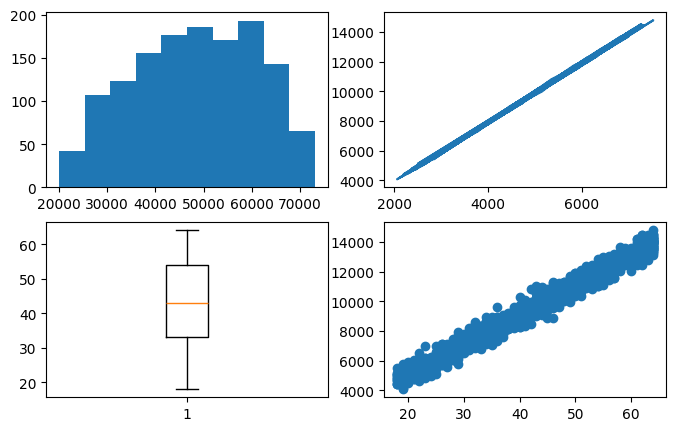

In [ ]:
fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(2,2,1)#top left
ax2 = fig.add_subplot(2,2,2)#top right
ax3 = fig.add_subplot(2,2,3)#bottom left
ax4 = fig.add_subplot(2,2,4) #bottom right
ax1.hist(cpi["Income"]) #mid class
ax2.plot(cpi["Last_Purchase_Amount"],cpi["Spending_Score"]) #a good direction for regerssion
ax3.boxplot(cpi["Age"])
ax4.scatter(cpi["Age"],cpi["Spending_Score"])
plt.show()

In [ ]:
cpi.columns

Index(['Number', 'Age', 'Income', 'Spending_Score', 'Membership_Years',
       'Purchase_Frequency', 'Last_Purchase_Amount'],
      dtype='object')

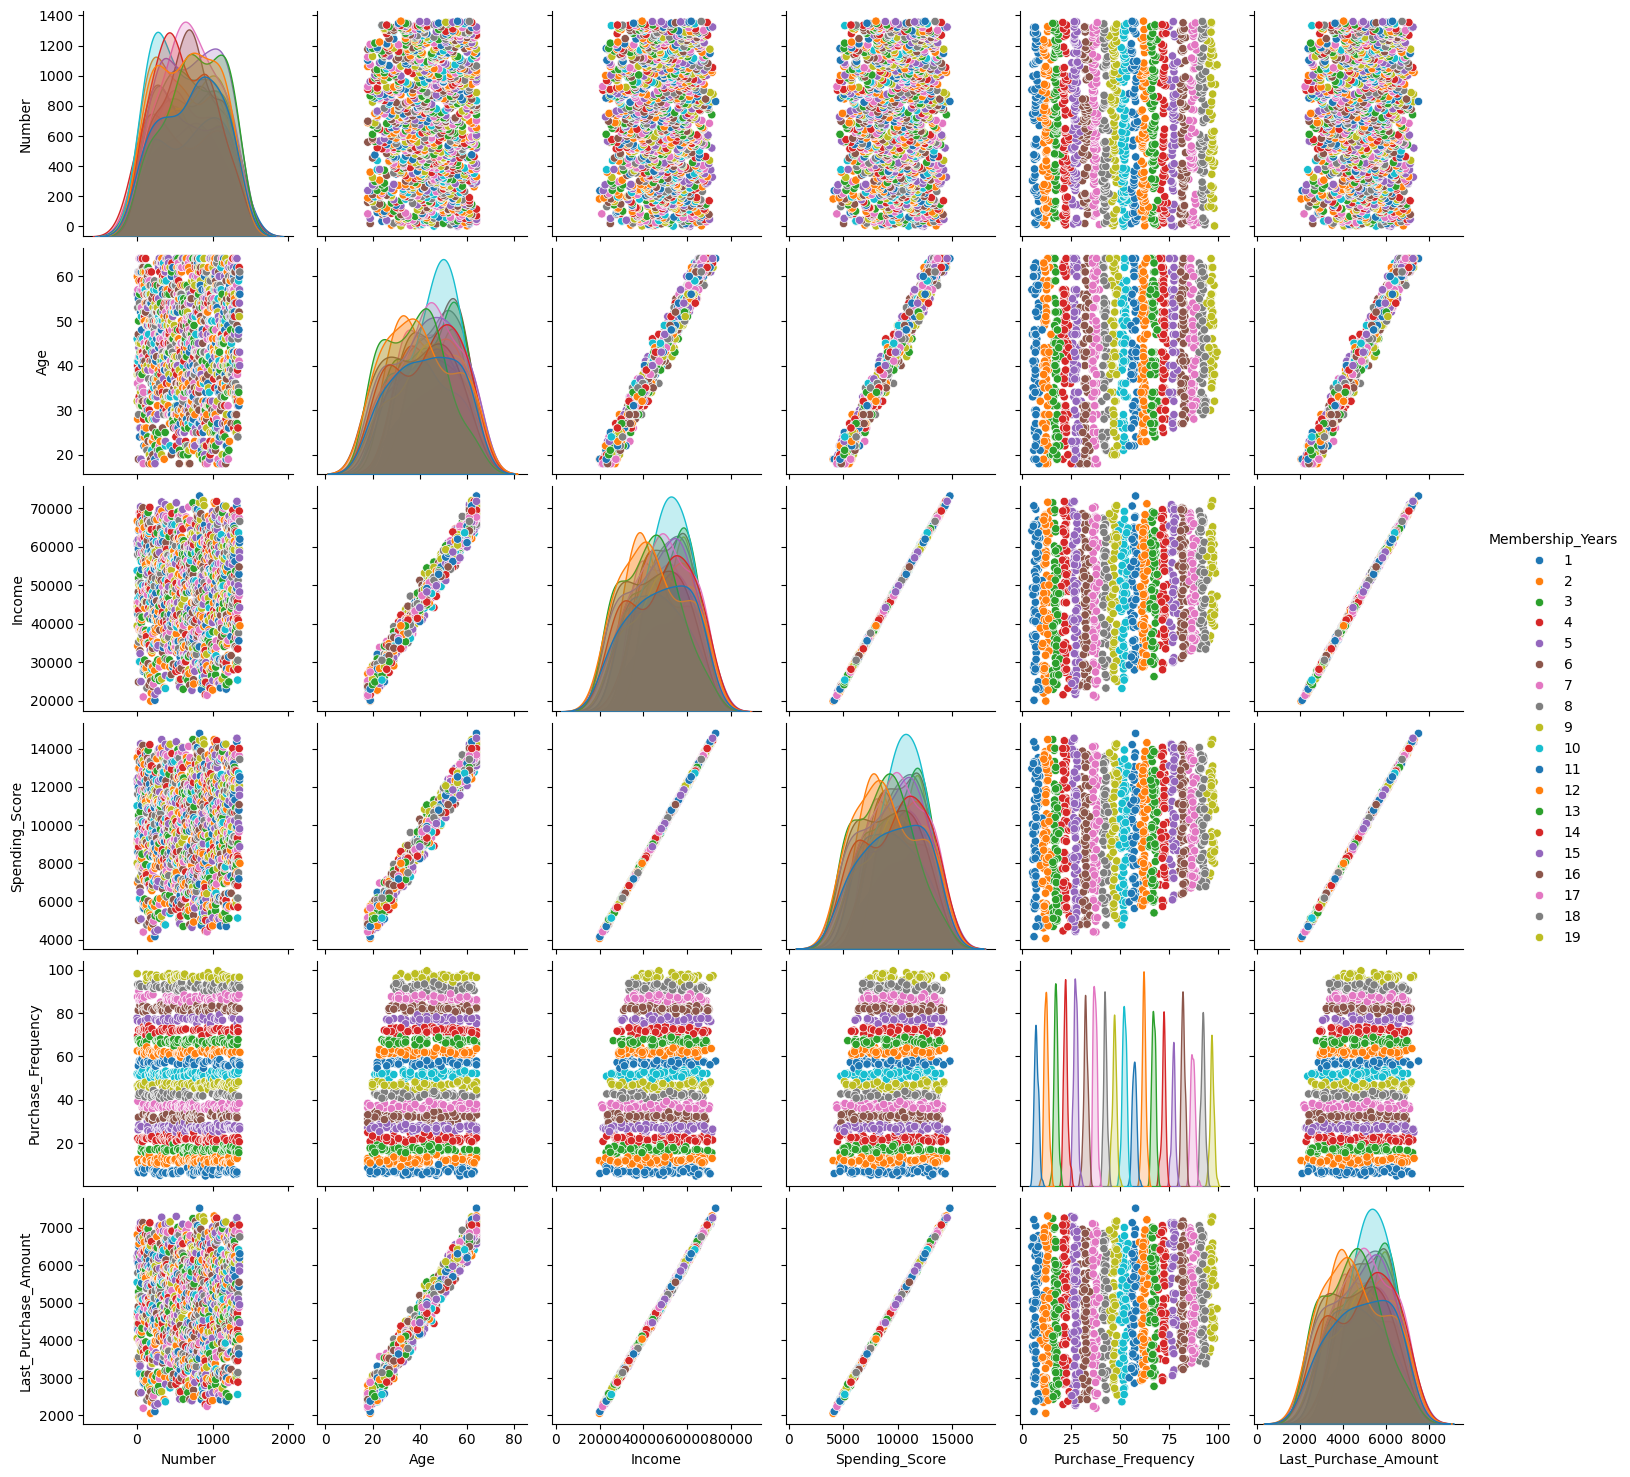

In [ ]:
import seaborn as sns
sns.pairplot(cpi,hue="Membership_Years",palette="tab10")

Text(0.5, 1.0, 'Age vs Spending Score')

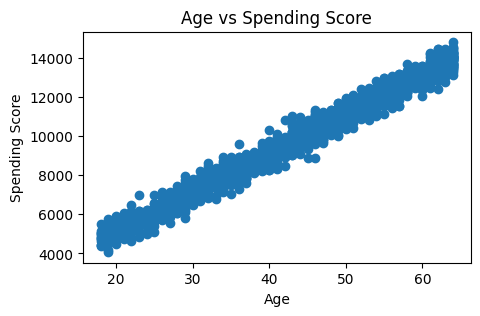

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(cpi["Age"],cpi["Spending_Score"])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
